<a href="https://colab.research.google.com/github/victormartinezf-droid/deepLearning/blob/main/Lab1_Search_Agent_8Puzzle_Didactico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 — Environment Setup, NumPy/Pandas y agente de búsqueda (8-Puzzle)

**Subject:** Artificial Intelligence & Deep Learning  
**Objective:** Follow the instructor's guide and produce an executable Google Colab notebook.

**Authors:**


*   Martinez Falcones Víctor
*   Moreira Santos Genoveva
*   Sanchez Pinargote Rafael



## What this lab must demonstrate
1. Setting up and using Google Colab with Python 3.
2. Performing a basic warm-up exercise with **NumPy** and **Pandas**.
3. Solving the same 8-puzzle using **BFS, DFS, and A\***.
4. Comparing **path length** and **expanded nodes**.
5. Saving the notebook to the course's GitHub repository.


## 1. Calentamiento: NumPy y Pandas



In [ ]:
import numpy as np
import pandas as pd

# NumPy: crea los números 0...11 y los organiza en una matriz de 3 filas x 4 columnas.
a = np.arange(12).reshape(3, 4)

print("Array:")
print(a)
print("\nMedia por columna:")
print(a.mean(axis=0))

# Pandas: ejemplo muy pequeño de una tabla de estudiantes y puntajes.
df = pd.DataFrame({
    "score": [12, 15, 9, 18],
    "student": ["A", "B", "C", "D"]
})

print("\nResumen estadístico:")
display(df.describe())


Array:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Media por columna:
[4. 5. 6. 7.]

Resumen estadístico:


,score
count,4.000000
mean,13.500000
std,3.872983
min,9.000000
25%,11.250000
50%,13.500000
75%,15.750000
max,18.000000


## 2. Entender el 8-puzzle antes de programar

The board has eight tiles and an empty space, represented here by `0`.

**Goal:**

```text
1 2 3
4 5 6
7 8 _
```

Each board state represents a possible situation. The agent seeks a sequence of moves that leads from the initial state to the goal.

- **State:** current configuration of the board.
- **Action:** move the empty space up, down, left, or right, when possible.
- **Goal:** reach the ordered board state.

In [ ]:
from collections import deque
import heapq
from itertools import count

GOAL = (1, 2, 3,
        4, 5, 6,
        7, 8, 0)

def show_board(state):
    """Muestra un estado del 8-puzzle de forma fácil de leer."""
    for i in range(0, 9, 3):
        row = ["_" if x == 0 else str(x) for x in state[i:i+3]]
        print(" ".join(row))


## 3. Generar los estados vecinos

The `neighbors()` function locates the `0` (empty space) and generates all valid boards that can be obtained with **a single move**.


In [ ]:
def neighbors(state):
    # Posición del espacio vacío.
    i = state.index(0)
    r, c = divmod(i, 3)

    possible_states = []

    # Arriba, abajo, izquierda, derecha.
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc

        if 0 <= nr < 3 and 0 <= nc < 3:
            j = nr * 3 + nc

            new_state = list(state)
            new_state[i], new_state[j] = new_state[j], new_state[i]

            possible_states.append(tuple(new_state))

    return possible_states


## 4. Reconstruir el camino encontrado

The algorithms will keep track of the "parent" state for each state. Upon reaching the goal, `reconstruct()` traces back to the start and returns the complete path.


In [ ]:
def reconstruct(parent, state):
    path = [state]

    while parent[path[-1]] is not None:
        path.append(parent[path[-1]])

    return list(reversed(path))


# Algoritmos de solución

| Algoritmo | Explicación               | Característica        |
| --------- | --------------------------- | --------------------- |
| **BFS**   | busca primero alrededor     | sistemático           |
| **DFS**   | toma un camino y profundiza | puede desviarse mucho |
| **A***    | busca pero usa una “pista”  | búsqueda informada    |


## 5. BFS — búsqueda en anchura

**Idea sencilla:** explora primero todos los estados cercanos, luego los que están un poco más lejos, y así sucesivamente.

En un problema donde cada movimiento cuesta lo mismo, BFS permite encontrar un camino de mínima longitud, aunque puede expandir muchos estados.



> **Simple idea:** first explore all nearby states, then those slightly further away, and so on.
> In a problem where every move has the same cost, BFS allows you to find a path of minimum length, although it may expand many states.




In [ ]:
def bfs(start):
    frontier = deque([start])
    visited = {start}
    parent = {start: None}
    expanded = 0

    while frontier:
        state = frontier.popleft()
        expanded += 1

        if state == GOAL:
            return reconstruct(parent, state), expanded

        for nxt in neighbors(state):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = state
                frontier.append(nxt)

    return None, expanded


## 6. DFS — búsqueda en profundidad

**Idea sencilla:** toma un camino y avanza por él todo lo posible antes de retroceder.

DFS puede encontrar una solución, pero **no garantiza el camino más corto**. Su comportamiento depende mucho del orden en que visite los vecinos.

> **Simple idea:** take a path and follow it as far as possible before backtracking. DFS can find a solution, but it **does not guarantee the shortest path**. Its behavior depends heavily on the order in which it visits neighbors.

In [ ]:
def dfs(start):
    stack = [start]
    visited = {start}
    parent = {start: None}
    expanded = 0

    while stack:
        state = stack.pop()
        expanded += 1

        if state == GOAL:
            return reconstruct(parent, state), expanded

        # reversed() solo fija un orden reproducible de exploración.
        for nxt in reversed(neighbors(state)):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = state
                stack.append(nxt)

    return None, expanded


## 7. A* — búsqueda informada

A\* no busca “a ciegas”. Combina:

- `g(n)`: costo real acumulado desde el inicio.
- `h(n)`: estimación de lo que falta hasta la meta.
- `f(n) = g(n) + h(n)`.

Para este laboratorio se usa la **distancia Manhattan**: cuántas posiciones horizontales y verticales separan cada ficha de su posición correcta.

> A* does not search "blindly." It combines:
> - `g(n)`: the actual cost accumulated from the start.
> - `h(n)`: an estimate of the remaining distance to the goal.
> - `f(n) = g(n) + h(n)`.
>
> For this lab, **Manhattan distance** is used: the number of horizontal and vertical positions separating each tile from its correct position.

In [ ]:
def manhattan(state):
    distance = 0

    for idx, value in enumerate(state):
        if value == 0:
            continue

        goal_r, goal_c = divmod(value - 1, 3)
        r, c = divmod(idx, 3)

        distance += abs(goal_r - r) + abs(goal_c - c)

    return distance


def astar(start):
    counter = count()

    # Elementos: (prioridad f, desempate, estado, costo g)
    frontier = [(manhattan(start), next(counter), start, 0)]

    parent = {start: None}
    g_score = {start: 0}
    expanded = 0

    while frontier:
        _, _, state, g = heapq.heappop(frontier)

        # Evita procesar entradas antiguas de la cola de prioridad.
        if g != g_score.get(state):
            continue

        expanded += 1

        if state == GOAL:
            return reconstruct(parent, state), expanded

        for nxt in neighbors(state):
            new_g = g + 1

            if nxt not in g_score or new_g < g_score[nxt]:
                g_score[nxt] = new_g
                parent[nxt] = state

                f = new_g + manhattan(nxt)
                heapq.heappush(
                    frontier,
                    (f, next(counter), nxt, new_g)
                )

    return None, expanded


## 8. Experimento 1: comparación sobre un mismo estado


In [ ]:
start = (4, 1, 3,
         2, 0, 8,
         7, 6, 5)

print("Estado inicial:")
show_board(start)

print("\nMeta:")
show_board(GOAL)


Estado inicial:
4 1 3
2 _ 8
7 6 5

Meta:
1 2 3
4 5 6
7 8 _


In [ ]:
path_bfs, exp_bfs = bfs(start)
path_dfs, exp_dfs = dfs(start)
path_astar, exp_astar = astar(start)

results = pd.DataFrame({
    "Algorithm": ["BFS", "DFS", "A*"],
    "Path length": [
        len(path_bfs) - 1,
        len(path_dfs) - 1,
        len(path_astar) - 1
    ],
    "Nodes expanded": [
        exp_bfs,
        exp_dfs,
        exp_astar
    ]
})

display(results)


,Algorithm,Path length,Nodes expanded
0,BFS,10,723
1,DFS,922,950
2,A*,10,33


# 9. Experimento 2: validación sobre los cinco estados mostrados en la guía

In [11]:
# ============================================================
# EXPERIMENTO 2
# Validación con los cinco estados mostrados en la guía
# ============================================================

# Estados mostrados por el profesor en "Expected Output"
professor_states = [
    (1, 7, 6, 2, 0, 8, 4, 5, 3),
    (1, 6, 4, 8, 5, 7, 2, 0, 3),
    (5, 3, 1, 4, 0, 8, 2, 6, 7),
    (2, 1, 4, 3, 5, 6, 7, 0, 8),
    (0, 6, 2, 5, 3, 8, 7, 4, 1)
]

algorithms = {
    "BFS": bfs,
    "DFS": dfs,
    "A*": astar
}

results_exp2 = []

# Ejecutar los tres algoritmos sobre cada uno de los cinco estados
for state_number, start_state in enumerate(professor_states, start=1):

    for algorithm_name, algorithm_function in algorithms.items():

        path, expanded = algorithm_function(start_state)

        results_exp2.append({
            "State": state_number,
            "Algorithm": algorithm_name,
            "Path length": len(path) - 1 if path is not None else None,
            "Nodes expanded": expanded
        })

# Crear tabla de resultados
df_exp2 = pd.DataFrame(results_exp2)

print("EXPERIMENT 2 - RESULTS")
print("Validation using the five states shown in the Lab 1 guide")
display(df_exp2)

EXPERIMENT 2 - RESULTS
Validation using the five states shown in the Lab 1 guide


,State,Algorithm,Path length,Nodes expanded
0,1,BFS,20,48630
1,1,DFS,49800,134880
2,1,A*,20,635
3,2,BFS,25,158525
4,2,DFS,63065,81025
5,2,A*,25,3306
6,3,BFS,22,93605
7,3,DFS,23028,162487
8,3,A*,22,996
9,4,BFS,19,29383


In [12]:
# ============================================================
# TABLA RESUMEN
# ============================================================

summary_exp2 = df_exp2.pivot(
    index="State",
    columns="Algorithm",
    values=["Path length", "Nodes expanded"]
)

display(summary_exp2)

Path length            Nodes expanded                
Algorithm          A* BFS    DFS             A*     BFS     DFS
State                                                          
1                  20  20  49800            635   48630  134880
2                  25  25  63065           3306  158525   81025
3                  22  22  23028            996   93605  162487
4                  19  19  49267            459   29383  135605
5                  26  26  33978           5089  160495   36147

### Interpretación de la tabla

- **Path length:** cantidad de movimientos de la solución encontrada. Menor es mejor.
- **Nodes expanded:** cantidad de estados que el algoritmo tuvo que examinar. Menor suele implicar una búsqueda más eficiente.

> - **Path length:** number of moves in the found solution. Lower is better.
> - **Nodes expanded:** number of states the algorithm had to examine. A lower number usually implies a more efficient search.

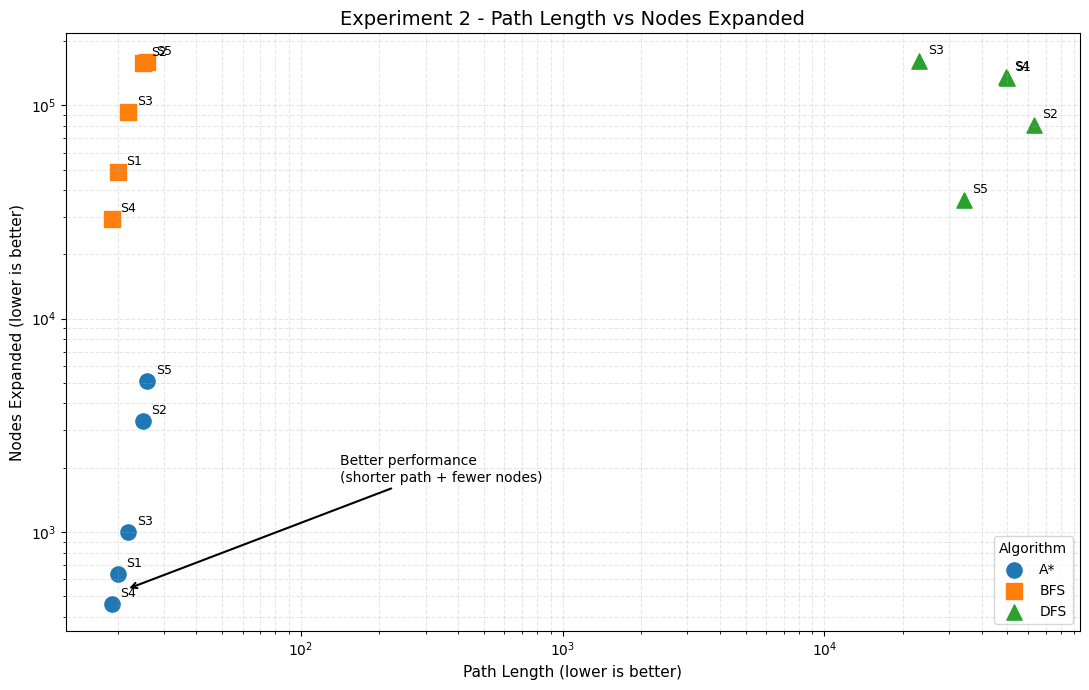

In [15]:
# ============================================================
# EXPERIMENTO 2
# Comparación conjunta: Path Length vs Nodes Expanded
# Menor en ambos indicadores = mejor desempeño
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 7))

# Un símbolo diferente para cada algoritmo
markers = {
    "A*": "o",
    "BFS": "s",
    "DFS": "^"
}

# Graficar cada algoritmo
for algorithm, marker in markers.items():

    data = df_exp2[df_exp2["Algorithm"] == algorithm]

    ax.scatter(
        data["Path length"],
        data["Nodes expanded"],
        s=120,
        marker=marker,
        label=algorithm
    )

    # Identificar a qué estado pertenece cada punto
    for _, row in data.iterrows():
        ax.annotate(
            f"S{int(row['State'])}",
            (row["Path length"], row["Nodes expanded"]),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9
        )

# Escala logarítmica:
# evita que los valores grandes de DFS oculten BFS y A*
ax.set_xscale("log")
ax.set_yscale("log")

# Títulos y etiquetas
ax.set_title(
    "Experiment 2 - Path Length vs Nodes Expanded",
    fontsize=14
)

ax.set_xlabel(
    "Path Length (lower is better)",
    fontsize=11
)

ax.set_ylabel(
    "Nodes Expanded (lower is better)",
    fontsize=11
)

# Cuadrícula
ax.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.30
)

# Leyenda
ax.legend(
    title="Algorithm"
)

# Indicar visualmente dónde está la zona de mejor desempeño
ax.annotate(
    "Better performance\n(shorter path + fewer nodes)",
    xy=(0.06, 0.07),
    xycoords="axes fraction",
    xytext=(0.27, 0.25),
    textcoords="axes fraction",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    ),
    fontsize=10
)

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot jointly compares the two evaluation criteria:
**path length** and **nodes expanded**. Lower values in both metrics
represent better search performance; therefore, points located closer
to the lower-left region of the graph represent more efficient solutions.

BFS and A* show similar horizontal positions because both obtained the
same optimal path length for the evaluated states. However, A* appears
substantially lower than BFS because it expanded considerably fewer
nodes.

DFS is located farther toward the upper-right region because it generally
produced longer solution paths and expanded more nodes.

Therefore, the graphical comparison shows that A* achieved the best
balance between solution quality and search effort for the five evaluated
8-puzzle states.